In this version, I try to import bcs from the gmsh grid

In [151]:
# Cell 1
import gmsh
import meshio
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt
from matplotlib.tri import Triangulation, LinearTriInterpolator

plt.rcParams.update({'figure.figsize': (8,6), 'font.size': 12})


In [152]:
# # Cell 2 - create mesh (modify geometry params to match your cavity)
#gmsh.initialize()
# gmsh.model.add("cavity_sf_pragmatic")

# length = 0.15   # z extent (m)
# radius = 0.15   # r extent (m)
# mesh_size = 0.005
# r_bore = 0.05     # bore radius (m) --- IGNORE ---

# p1 = gmsh.model.geo.addPoint(0.0, 0.0, 0, mesh_size)
# p2 = gmsh.model.geo.addPoint(length, 0.0, 0, mesh_size)
# p3 = gmsh.model.geo.addPoint(length, radius, 0, mesh_size)
# p4 = gmsh.model.geo.addPoint(0.0, radius, 0, mesh_size)

# l1 = gmsh.model.geo.addLine(p1, p2)
# l2 = gmsh.model.geo.addLine(p2, p3)
# l3 = gmsh.model.geo.addLine(p3, p4)
# l4 = gmsh.model.geo.addLine(p4, p1)

# cl = gmsh.model.geo.addCurveLoop([l1, l2, l3, l4])
# surf = gmsh.model.geo.addPlaneSurface([cl])

# gmsh.model.geo.synchronize()
# gmsh.model.mesh.generate(2)
# mshfile = "cavity_sf_pragmatic.msh"
# gmsh.write(mshfile)
# gmsh.finalize()
'''mesh = meshio.read('/Users/straniero/Documents/Dphil/hyperfish/ell_shape_new.msh')
points = mesh.points[:, :2].copy()   # (z,r)
cells = None
for cb in mesh.cells:
    if cb.type == "triangle":
        cells = cb.data.copy()
        break
if cells is None:
    raise RuntimeError("No triangles found in mesh.")

print("Mesh: nodes =", points.shape[0], "triangles =", cells.shape[0])'''



'mesh = meshio.read(\'/Users/straniero/Documents/Dphil/hyperfish/ell_shape_new.msh\')\npoints = mesh.points[:, :2].copy()   # (z,r)\ncells = None\nfor cb in mesh.cells:\n    if cb.type == "triangle":\n        cells = cb.data.copy()\n        break\nif cells is None:\n    raise RuntimeError("No triangles found in mesh.")\n\nprint("Mesh: nodes =", points.shape[0], "triangles =", cells.shape[0])'

In [153]:
import numpy as np
mesh = meshio.read('/Users/straniero/Documents/Dphil/hyperfish/ell_shape_new.msh')
points = mesh.points[:, :2].copy()   # (z,r)
cells = None
for cb in mesh.cells:
    if cb.type == "triangle":
        cells = cb.data.copy()
        break
if cells is None:
    raise RuntimeError("No triangles found in mesh.")

print("Mesh: nodes =", points.shape[0], "triangles =", cells.shape[0])

# --- start from your variables ---
# mesh = meshio.read('/path/to/ell_shape_new.msh')
# points = mesh.points[:, :2].copy()
# cells = ... (triangle block)
n_points = points.shape[0]

# mapping tag -> name if available
tag_to_name = {}
if getattr(mesh, "field_data", None):
    for name, arr in mesh.field_data.items():
        # arr usually [dim, tag] or [tag]
        tag = int(arr[1]) if len(arr) > 1 else int(arr[0])
        tag_to_name[tag] = name

# prepare outputs
is_on_boundary = np.zeros(n_points, dtype=bool)
# For storing physical group names per node (set because node may be in multiple groups)
node_phys_names = [set() for _ in range(n_points)]

# helper to attach a physical tag -> name to a node
def attach_tag_to_node(node_idx, tag):
    if tag is None:
        return
    try:
        tag_int = int(tag)
    except:
        return
    name = tag_to_name.get(tag_int, None)
    if name is not None:
        node_phys_names[node_idx].add(name)
    else:
        # fallback: store tag string if name not available
        node_phys_names[node_idx].add(f"tag_{tag_int}")

# 1) Check for explicit vertex / point cell blocks (0D)
vertex_types = {"vertex", "point", "points"}
found_any = False
for idx, cb in enumerate(mesh.cells):
    ctype = cb.type.lower()
    if ctype in vertex_types:
        found_any = True
        node_indices = cb.data.flatten()
        # corresponding cell_data arrays (if present) are in mesh.cell_data["gmsh:physical"]
        phys_blocks = mesh.cell_data.get("gmsh:physical", None)
        phys_for_block = None
        if phys_blocks is not None and idx < len(phys_blocks):
            phys_for_block = phys_blocks[idx]
        for i, node in enumerate(node_indices):
            is_on_boundary[int(node)] = True
            if phys_for_block is not None:
                tag = phys_for_block[i]
                attach_tag_to_node(int(node), tag)

# 2) Check for explicit 1D boundary elements (lines / segments)
one_d_types = {"line", "line3", "segment", "bar", "edge"}
found_1d = False
for idx, cb in enumerate(mesh.cells):
    ctype = cb.type.lower()
    if ctype in one_d_types:
        found_1d = True
        edges = cb.data  # shape (m, 2) or (m, 3) for higher-order; take first two nodes for topology
        phys_blocks = mesh.cell_data.get("gmsh:physical", None)
        phys_for_block = phys_blocks[idx] if (phys_blocks is not None and idx < len(phys_blocks)) else None
        for j, ent in enumerate(edges):
            # some line element types may be shape (m,2) or (m,3) (with mid nodes); take unique endpoints
            # endpoints = (ent[0], ent[-1]) to be robust
            n0 = int(ent[0]); n1 = int(ent[-1])
            is_on_boundary[n0] = True
            is_on_boundary[n1] = True
            if phys_for_block is not None:
                tag = phys_for_block[j]
                attach_tag_to_node(n0, tag)
                attach_tag_to_node(n1, tag)

# 3) Fallback: if no explicit 1D or vertex blocks, find boundary from triangle connectivity
if not found_any and not found_1d:
    # build edge counts from triangles
    # triangles are in `cells` variable you already extracted (Ntri x 3)
    tri = cells.astype(np.int64)
    # produce canonical ordered edges (min,max) for counting
    e01 = np.vstack([tri[:,0], tri[:,1]]).T
    e12 = np.vstack([tri[:,1], tri[:,2]]).T
    e20 = np.vstack([tri[:,2], tri[:,0]]).T
    all_edges = np.vstack([e01, e12, e20])
    # canonicalize
    mins = np.minimum(all_edges[:,0], all_edges[:,1])
    maxs = np.maximum(all_edges[:,0], all_edges[:,1])
    can_edges = np.vstack([mins, maxs]).T
    # count unique edges
    # view as structured to use numpy unique
    dtype = np.dtype([('a', can_edges.dtype), ('b', can_edges.dtype)])
    can_edges_view = can_edges.view(dtype)
    uniq, counts = np.unique(can_edges_view, return_counts=True)
    # edges that appear once are boundary edges
    boundary_mask = counts == 1
    boundary_edges = np.vstack([uniq['a'][boundary_mask], uniq['b'][boundary_mask]]).T
    # mark nodes on these edges
    for e in boundary_edges:
        n0, n1 = int(e[0]), int(e[1])
        is_on_boundary[n0] = True
        is_on_boundary[n1] = True
    # Note: triangle-only meshes rarely contain gmsh:physical tags for edges in meshio output.
    # If the original .msh had physical groups for boundary lines but meshio didn't write line cells,
    # prefer reading via the gmsh Python API for robust retrieval of physical point groups.

# summary
num_boundary = int(is_on_boundary.sum())
print(f"Total points: {n_points}; boundary points: {num_boundary}")

# optional: create an integer mask (0/1) or indices
boundary_indices = np.nonzero(is_on_boundary)[0]
boundary_mask_int = is_on_boundary.astype(np.uint8)  # 1 for boundary, 0 otherwise

# show a small sample of boundary nodes with any physical names found
sample_show = 20
print("Sample boundary indices (first {}): {}".format(sample_show, boundary_indices[:sample_show].tolist()))
# show names for a few (if any)
named = [(i, sorted(list(node_phys_names[i]))) for i in boundary_indices if node_phys_names[i]]
print("Boundary nodes with physical names (up to 20):", named[:20])

# Now you have:
# - is_on_boundary (bool array)
# - boundary_mask_int (0/1 uint8 array)
# - boundary_indices (list of indices)
# - node_phys_names (list of sets of names for each node)


Mesh: nodes = 2128 triangles = 4076
Total points: 2128; boundary points: 129
Sample boundary indices (first 20): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
Boundary nodes with physical names (up to 20): [(np.int64(0), ['domain']), (np.int64(1), ['domain']), (np.int64(2), ['domain']), (np.int64(3), ['domain']), (np.int64(4), ['domain']), (np.int64(5), ['domain']), (np.int64(6), ['domain']), (np.int64(7), ['domain']), (np.int64(8), ['domain']), (np.int64(9), ['domain']), (np.int64(10), ['domain']), (np.int64(11), ['domain']), (np.int64(12), ['domain']), (np.int64(13), ['domain']), (np.int64(14), ['domain']), (np.int64(15), ['domain']), (np.int64(16), ['domain']), (np.int64(17), ['domain']), (np.int64(18), ['domain']), (np.int64(19), ['domain'])]


In [154]:
# Cell 3 - assemble A and M using dodecagon numeric integrals
n_nodes = points.shape[0]
n_tris = cells.shape[0]

# Precompute triangle centroids, areas, side-midpoints, and shape-function gradients
tri_centroid = np.zeros((n_tris,2))
tri_area = np.zeros(n_tris)
tri_side_mid = np.zeros((n_tris,3,2))
tri_grads = np.zeros((n_tris,3,2))  # grad phi for local nodes (d/dz, d/dr)
for t_idx, tri in enumerate(cells):
    coords = points[tri]
    tri_centroid[t_idx] = coords.mean(axis=0)
    x1,y1 = coords[0]; x2,y2 = coords[1]; x3,y3 = coords[2]
    tri_area[t_idx] = 0.5 * abs((x2-x1)*(y3-y1) - (x3-x1)*(y2-y1))
    tri_side_mid[t_idx,0] = 0.5*(coords[0] + coords[1])  # midpoint of (0,1)
    tri_side_mid[t_idx,1] = 0.5*(coords[1] + coords[2])  # midpoint of (1,2)
    tri_side_mid[t_idx,2] = 0.5*(coords[2] + coords[0])  # midpoint of (2,0)
    # shape function grads: phi = a + b z + c r  => grads = [b, c]
    A_mat = np.array([[1.0, coords[0,0], coords[0,1]],
                      [1.0, coords[1,0], coords[1,1]],
                      [1.0, coords[2,0], coords[2,1]]])
    invA = np.linalg.inv(A_mat)
    # column j of invA gives coefficients [a,b,c] for phi_j so gradient = [b,c] = invA[1:, j]
    for local_j in range(3):
        coef = invA[:, local_j]   # [a,b,c]
        tri_grads[t_idx, local_j, 0] = coef[1]
        tri_grads[t_idx, local_j, 1] = coef[2]

# containers for sparse accumulation (use dict-of-dicts then convert)
from collections import defaultdict
A_rows = [defaultdict(float) for _ in range(n_nodes)]
M_rows = [defaultdict(float) for _ in range(n_nodes)]

def tri_area_from_pts(p1,p2,p3):
    (x1,y1),(x2,y2),(x3,y3) = (p1,p2,p3)
    return 0.5 * abs((x2-x1)*(y3-y1) - (x3-x1)*(y2-y1))

# Loop over triangles and their 3 corner subtriangles
for t_idx, tri in enumerate(cells):
    centroid = tri_centroid[t_idx]
    coords = points[tri]
    grads = tri_grads[t_idx]   # (3,2)
    # For corner k: use subtriangle (centroid, midpoint of side opposite corner? we use consistent mapping)
    # We'll define subtriangle for corner local_k with vertices: centroid, midpoint of side adjacent to corner, corner point.
    # Which midpoint? For corner 0 use midpoint of (2,0) (tri_side_mid[...,2]); corner1 -> mid(0,1) (index 0); corner2 -> mid(1,2) (index1).
    # This order matches earlier derivation.
    mapping = {0:2, 1:0, 2:1}
    for local_k in range(3):
        global_k = tri[local_k]
        mid = tri_side_mid[t_idx, mapping[local_k]]
        v_corner = coords[local_k]
        sub_a = tri_area_from_pts(centroid, mid, v_corner)
        if sub_a <= 0: 
            continue
        # r weight approx by mean r at subtriangle vertices (centroid, mid, corner)
        r_c = (centroid[1] + mid[1] + v_corner[1]) / 3.0

        # Mass contributions: for parent local_j in [0,1,2], integrate phi_j over subtriangle:
        # exact integral = area_sub * average(phi_j over subtriangle),
        # and phi_j at any point p = [1, x, y] dot invA[:, local_j] (we computed invA earlier only inside loop, but we recompute here)
        # Let's compute invA for this parent triangle:
        A_mat = np.array([[1.0, coords[0,0], coords[0,1]],
                          [1.0, coords[1,0], coords[1,1]],
                          [1.0, coords[2,0], coords[2,1]]])
        invA = np.linalg.inv(A_mat)
        pts = [centroid, mid, v_corner]
        for local_j in range(3):
            global_j = tri[local_j]
            phi_vals = []
            for p in pts:
                v = np.array([1.0, p[0], p[1]])
                phi_vals.append(float(v @ invA[:, local_j]))
            avg_phi = sum(phi_vals) / 3.0
            m_contrib = sub_a * avg_phi * r_c    # includes r-weight
            if abs(m_contrib) > 0:
                M_rows[global_k][global_j] += m_contrib

        # Stiffness contributions: integrate (grad phi_local_k · grad phi_local_j) * r_c * area_sub
        gk = grads[local_k]   # gradient for phi at corner local_k
        for local_j in range(3):
            global_j = tri[local_j]
            gj = grads[local_j]
            k_contrib = float((gk @ gj) * (r_c * sub_a))
            if abs(k_contrib) > 0:
                A_rows[global_k][global_j] += k_contrib

# Convert dict-of-dicts to sparse matrices
rowA=[]; colA=[]; dataA=[]
rowM=[]; colM=[]; dataM=[]
for i in range(n_nodes):
    for j, val in A_rows[i].items():
        if abs(val) > 0:
            rowA.append(i); colA.append(j); dataA.append(val)
    for j, val in M_rows[i].items():
        if abs(val) > 0:
            rowM.append(i); colM.append(j); dataM.append(val)

A_mat = sp.coo_matrix((dataA, (rowA, colA)), shape=(n_nodes, n_nodes)).tocsr()
M_mat = sp.coo_matrix((dataM, (rowM, colM)), shape=(n_nodes, n_nodes)).tocsr()

print("Assembled matrices: A nnz =", A_mat.nnz, ", M nnz =", M_mat.nnz)


Assembled matrices: A nnz = 14534 , M nnz = 14534


In [155]:
# Cell 4 - identify Dirichlet (metal) boundary nodes

dirichlet_nodes = np.where(is_on_boundary)[0] #| on_zL)[0]  # for superfish-like we only do r=R and z=0 as Dirichlet; z=L is ignored (Neumann)
dirichlet_mask = np.zeros(n_nodes, dtype=bool)
dirichlet_mask[dirichlet_nodes] = True
print("Dirichlet nodes:", dirichlet_nodes.size)

# Build index maps for reduced system
free_idx = np.where(~dirichlet_mask)[0]
n_free = free_idx.size
print("Free DOFs:", n_free)

# Permutation: free nodes first
perm = np.concatenate((free_idx, dirichlet_nodes))
invperm = np.zeros_like(perm)
invperm[perm] = np.arange(n_nodes)

A_perm = A_mat[perm,:][:,perm].tocsr()
M_perm = M_mat[perm,:][:,perm].tocsr()

# Extract reduced submatrices
A_red = A_perm[:n_free, :n_free].tocsr()
M_red = M_perm[:n_free, :n_free].tocsr()


Dirichlet nodes: 129
Free DOFs: 1999


Selected driving node: 1153 coords (z,r) = [0.02862316 0.00518955]
No eigenvalues present; using rough initial k^2 guess: 889.6016444003033
Solved (A - k^2 M) H = g. Driving node H value (complex) = (5765.595666205504+0j)
Abs(H_driving) = 5765.595666205504


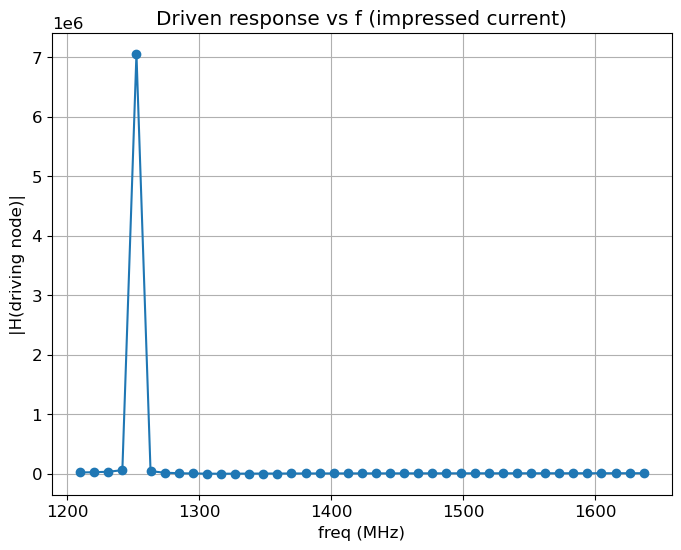

In [156]:
# ---------------------------
# Cell C (self-contained): set an impressed driving current and solve (A - k^2 M) H = g
# Insert this cell immediately after Cell 4 (Dirichlet elimination).
# Requires: A_mat, M_mat, points, dirichlet_mask, free_idx, perm, A_red, M_red
# ---------------------------

import numpy as np
from scipy.sparse.linalg import spsolve
import scipy.sparse as sp

# ---------- helper: ensure required variables exist ----------
n_nodes = points.shape[0]


# free indices and permutation (free DOFs first)
free_idx = np.where(~dirichlet_mask)[0]
dirichlet_nodes = np.where(dirichlet_mask)[0]
perm = np.concatenate((free_idx, dirichlet_nodes))
invperm = np.zeros_like(perm); invperm[perm] = np.arange(n_nodes)
n_free = free_idx.size

# Get reduced operators (if not already available)
A_perm = A_mat[perm,:][:,perm].tocsr()
M_perm = M_mat[perm,:][:,perm].tocsr()
A_red = A_perm[:n_free, :n_free].tocsr()
M_red = M_perm[:n_free, :n_free].tocsr()

# ---------- helper: extract dodecagon mass row for node d ----------
def get_node_mass_row_from_Mmat(d, Mfull):
    """Return dict j->m_{d,j} and total mass (r-weighted area of dodecagon).
       Uses sparse Mfull (global ordering).
    """
    row = Mfull.getrow(d).tocoo()
    if row.nnz == 0:
        return {}, 0.0
    mrow = {int(j): float(v) for j,v in zip(row.col, row.data)}
    total = sum(mrow.values())
    return mrow, total

# ---------- choose a driving node ----------
# prefer an interior off-axis node (not dirichlet and r>0)
candidates = [i for i in range(n_nodes) if (not dirichlet_mask[i]) and (points[i,1] > 1e-6)]
if len(candidates) == 0:
    # fallback: any non-dirichlet node
    candidates = [i for i in range(n_nodes) if (not dirichlet_mask[i])]
if len(candidates) == 0:
    raise RuntimeError("No interior node available as driving node. Check mesh / dirichlet masks.")
driving_node = candidates[len(candidates)//2]  # pick middle candidate (deterministic)
print("Selected driving node:", driving_node, "coords (z,r) =", points[driving_node])

# ---------- build impressed-current RHS g (global ordering) ----------
mrow, total_r = get_node_mass_row_from_Mmat(driving_node, M_mat)
if total_r <= 0 or len(mrow)==0:
    raise RuntimeError("Driving node's dodecagon has zero r-weighted area or M row is empty. Choose another node.")

I_val = 10  # total impressed current (arbitrary units)
g_full = np.zeros(n_nodes, dtype=float)
for j, mval in mrow.items():
    g_full[j] = I_val * (mval / total_r)

# Permute RHS consistent with reduced system (free DOFs first)
g_perm = g_full[perm]
g_red = g_perm[:n_free]

# ---------- choose k^2 to solve for ----------
# If an eigen-solve has already been performed and 'vals' exists, use the closest computed eigenvalue as initial k^2.
# try:
#     mode_index  # if defined we can use it; else default 0
# except NameError:
#     mode_index = 0

# if 'vals' in globals() and len(vals)>0:
#     # use eigenvalue slightly off to avoid singular solve
#     k2 = float(vals[mode_index]) * 0.995
#     print("Using k^2 near computed eigenvalue (slightly offset):", k2)

# fallback: pick a reasonable k2 using a rough wavelength estimate based on cavity size
# use k ~ pi / radius as a rough guess for first TM-like mode
rough_k = np.pi / max(points[:,1].max(), 1e-3)
k2 = rough_k**2
print("No eigenvalues present; using rough initial k^2 guess:", k2)

# ---------- solve (A_red - k^2 M_red) H_red = g_red ----------
Aop = (A_red - k2 * M_red).tocsc()
try:
    H_red = spsolve(Aop, g_red)
except Exception as e:
    # try slight damping (complex shift) to regularize if singular
    eps_shift = 1e-9
    print("Direct solve failed (maybe near resonance):", e)
    print("Retrying with tiny complex damping shift on k^2...")
    Aop_shift = (A_red - (k2*(1+1j*eps_shift)) * M_red).tocsc()
    H_red = spsolve(Aop_shift, g_red)

# ---------- reconstruct full H (global ordering) ----------
H_perm = np.zeros(n_nodes, dtype=np.complex128)
H_perm[:n_free] = H_red
H_perm[n_free:] = 0.0   # Dirichlet DOFs are zero
H_full = np.zeros(n_nodes, dtype=np.complex128)
H_full[perm] = H_perm

# normalize for visualization (optional)
# if np.max(np.abs(H_full)) > 0:
#     H_full = H_full / np.max(np.abs(H_full))

print("Solved (A - k^2 M) H = g. Driving node H value (complex) =", H_full[driving_node])
print("Abs(H_driving) =", abs(H_full[driving_node]))

# ---------- (optional) small frequency sweep to inspect driven response ----------
do_sweep = True   # set True if you want a quick sweep
if do_sweep:
    c = 299792458.0
    # pick a frequency window around the rough k2 above
    k_center = np.sqrt(k2)
    f_center = c*k_center / (2*np.pi)
    df = 0.15 * f_center
    fvals = np.linspace(f_center - df, f_center + df, 41)
    Ivals = []
    for f in fvals:
        k2_try = (2*np.pi*f / c)**2
        Aop_try = (A_red - k2_try*M_red).tocsc()
        try:
            Hr = spsolve(Aop_try, g_red)
            Htmp = np.zeros(n_nodes, dtype=np.complex128); Htmp[perm[:n_free]] = Hr
            Ivals.append(np.abs(Htmp[driving_node]))
        except Exception:
            Ivals.append(np.nan)
    plt.plot(fvals/1e6, Ivals, '-o')
    plt.xlabel('freq (MHz)')
    plt.ylabel('|H(driving node)|')
    plt.title('Driven response vs f (impressed current)')
    plt.grid(True)
    plt.show()

# ---------- done ----------
# You now have H_full (complex nodal H). Use it to compute E fields and plot streamlines as before.


In [157]:
# Cell 5 - eigen solve
k_eigs = 20  # number of eigenpairs
c = 299792458.0

# Solve the reduced generalized eigenproblem without depending on the driven-response cell.
vals, vecs = spla.eigsh(A_red, k=min(k_eigs, n_free - 2), M=M_red, sigma=0.0, which='LM', tol=1e-9, maxiter=8000)

idx = np.argsort(np.real(vals))
vals = np.maximum(np.real(vals[idx]), 0.0)
vecs = vecs[:, idx]

kvals = np.sqrt(vals)
freqs = kvals * c / (2*np.pi)
print("Frequencies (MHz):", freqs/1e6)


Frequencies (MHz): [1276.35071864 1911.4399798  2076.59833554 2727.09761096 2907.35428446
 2981.82432624 3337.53210043 3513.02764427 3634.54750837 3897.3481823
 4131.54409625 4313.38278978 4470.49019872 4677.70514812 4764.92615126
 4915.35264294 4982.85546968 5138.03976853 5364.58997292 5576.00282952
 5605.45789817 5748.59824012 5778.51101788 6011.11715126 6097.80180978
 6186.1811403  6270.70723658 6459.22596386 6514.08544585 6595.40445485]


In [158]:
# Cell 6 - reconstruct full H for a chosen mode index
if 'vecs' not in globals():
    raise RuntimeError('Run Cell 7 first so the eigenvectors vecs are available.')

mode_index = 0  # choose which computed eigenmode (0-based)
mode_index = max(0, min(mode_index, vecs.shape[1] - 1))
print("Using mode index:", mode_index, "frequency (MHz):", freqs[mode_index] / 1e6)

H_free = vecs[:, mode_index].astype(np.complex128)
H_full = np.zeros(n_nodes, dtype=np.complex128)
H_full[free_idx] = H_free

if np.max(np.abs(H_full)) > 0:
    H_full = H_full / np.max(np.abs(H_full))


In [159]:
# Cell 7 - compute nodal gradients
n_tri = cells.shape[0]
tri_gradH = np.zeros((n_tri,2), dtype=np.complex128)
tri_cent = tri_centroid  # from earlier

for t_idx, tri in enumerate(cells):
    grads = tri_grads[t_idx]   # (3,2)
    H_local = H_full[tri]      # H at the three triangle nodes
    # grad H = sum_i H_i * grad phi_i
    gradH = H_local @ grads    # shape (2,)
    tri_gradH[t_idx,:] = gradH

# average to nodes (area-weighted)
gradH_nodes = np.zeros((n_nodes,2), dtype=np.complex128)
area_accum = np.zeros(n_nodes, dtype=float)
for t_idx, tri in enumerate(cells):
    a = tri_area[t_idx]
    for ni in tri:
        gradH_nodes[ni] += tri_gradH[t_idx] * a
        area_accum[ni] += a
nonzero = area_accum > 0
gradH_nodes[nonzero] /= area_accum[nonzero][:,None]
gradH_nodes[~nonzero] = 0.0

dH_dz = gradH_nodes[:,0]
dH_dr = gradH_nodes[:,1]


Grid points: total=90000, inside mesh=59434, outside=30566
Inside field magnitude: min=4.344e+00, max=2.339e+16, mean=2.182e+14
Seeding 254 streamlines (inside mesh).


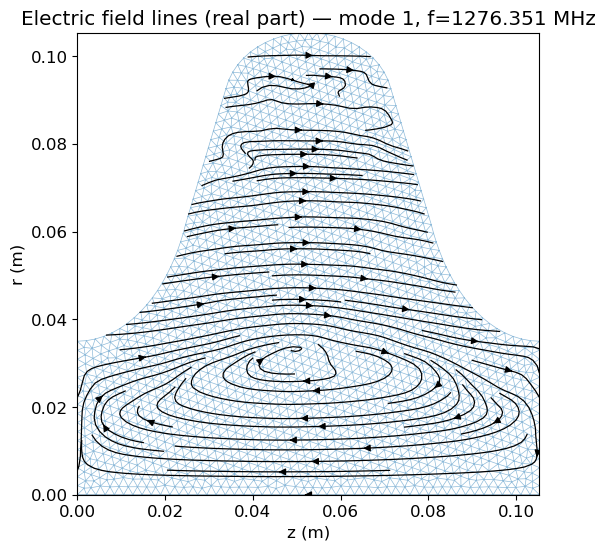

In [160]:
# Cell 8 - compute E fields and plot field lines
eps0 = 8.8541878128e-12
omega = 2*np.pi * freqs[mode_index]   # angular frequency for the chosen mode
j = 1j
prefactor = 1.0 / ( omega * eps0)

H_nodes = H_full
r_nodes = points[:,1]
r_safe = np.maximum(r_nodes, 1e-12)

E_r_nodes = -0.1*prefactor * dH_dz
E_z_nodes =  prefactor * (dH_dr + H_nodes / r_safe)

# Use real part for instantaneous field snapshot
Ez_plot = E_z_nodes.real
Er_plot = E_r_nodes.real

# triangulation from mesh
triang = Triangulation(points[:,0], points[:,1], cells)

# 1D coordinate vectors (x = z_grid, y = r_grid)
nx = 300
ny = 300
z_min, z_max = points[:,0].min(), points[:,0].max()
r_min, r_max = points[:,1].min(), points[:,1].max()
z_grid = np.linspace(z_min, z_max, nx)
r_grid = np.linspace(r_min, r_max, ny)

# meshgrid with shapes (ny, nx) -> Z rows correspond to r, columns to z
Z, R = np.meshgrid(z_grid, r_grid)

# tri finder: returns triangle index for each (x,y) point or -1 if outside
finder = triang.get_trifinder()
tri_ids = finder(Z, R)   # shape (ny, nx)

# Diagnostics
n_total = tri_ids.size
n_inside = np.count_nonzero(tri_ids != -1)
print(f"Grid points: total={n_total}, inside mesh={n_inside}, outside={n_total-n_inside}")
if n_inside == 0:
    raise RuntimeError("No grid points fall inside the triangulation hull. Reduce grid extent or refine mesh.")

# Interpolate only at inside points using LinearTriInterpolator (faster than calling on entire grid)
interp_Ez = LinearTriInterpolator(triang, Ez_plot)
interp_Er = LinearTriInterpolator(triang, Er_plot)

# initialize arrays (ny, nx)
Ez_grid = np.zeros_like(Z, dtype=float)
Er_grid = np.zeros_like(Z, dtype=float)

# Evaluate interpolator at inside points and fill arrays
pts_x = Z[tri_ids != -1].ravel()
pts_y = R[tri_ids != -1].ravel()
vals_Ez = interp_Ez(pts_x, pts_y)
vals_Er = interp_Er(pts_x, pts_y)

# LinearTriInterpolator returns masked arrays sometimes; convert to float and handle mask
def _to_float_arr(v):
    if hasattr(v, "mask"):
        arr = np.array(v.filled(np.nan), dtype=float)
    else:
        arr = np.array(v, dtype=float)
    return arr

vals_Ez = _to_float_arr(vals_Ez)
vals_Er = _to_float_arr(vals_Er)

# Fill into Ez_grid / Er_grid
Ez_grid_flat = Ez_grid.ravel()
Er_grid_flat = Er_grid.ravel()
inside_idx_flat = np.flatnonzero(tri_ids.ravel() != -1)
Ez_grid_flat[inside_idx_flat] = vals_Ez
Er_grid_flat[inside_idx_flat] = vals_Er
Ez_grid = Ez_grid_flat.reshape(Ez_grid.shape)
Er_grid = Er_grid_flat.reshape(Er_grid.shape)

# As a safety, replace any remaining NaN with 0
Ez_grid = np.nan_to_num(Ez_grid, nan=0.0)
Er_grid = np.nan_to_num(Er_grid, nan=0.0)

# Quick magnitude diagnostic (inside only)
E_mag_inside = np.sqrt(Ez_grid[tri_ids!=-1]**2 + Er_grid[tri_ids!=-1]**2)
print(f"Inside field magnitude: min={E_mag_inside.min():.3e}, max={E_mag_inside.max():.3e}, mean={E_mag_inside.mean():.3e}")

# If the field is extremely small relative to rounding, you may want to scale it for visualization:
scale_for_plot = 1.0
if E_mag_inside.max() < 1e-12:
    scale_for_plot = 1e12
    print("Fields very small; scaling by", scale_for_plot, "for visibility.")
Ez_plot_grid = Ez_grid * scale_for_plot
Er_plot_grid = Er_grid * scale_for_plot

# Choose seed points automatically from inside region (optional). Streamplot can generate seeds itself,
# but sometimes start_points give more reliable streamlines.
seed_nx = 20
seed_ny = 20
seed_z = np.linspace(z_min + 1e-6, z_max - 1e-6, seed_nx)
seed_r = np.linspace(r_min + 1e-6, r_max - 1e-6, seed_ny)
SZ, SR = np.meshgrid(seed_z, seed_r)
seed_tri_ids = finder(SZ, SR)
seed_points = np.column_stack((SZ[seed_tri_ids!=-1].ravel(), SR[seed_tri_ids!=-1].ravel()))
print(f"Seeding {seed_points.shape[0]} streamlines (inside mesh).")



# Now plot only field lines for E (no background)
plt.figure(figsize=(8,6))
plt.triplot(points[:,0], points[:,1], cells, lw=0.5, alpha=0.5)
plt.gca().set_aspect('equal')


plt.streamplot(
    z_grid,
    r_grid,
    Ez_plot_grid,    # U (x-direction)
    Er_plot_grid,    # V (y-direction)
    density=2.0,
    linewidth=0.9,
    arrowsize=1.0,
    color='black',
    start_points=seed_points if seed_points.size>0 else None
)
plt.title(f"Electric field lines (real part) — mode {mode_index+1}, f={freqs[mode_index]/1e6:.3f} MHz")
plt.xlabel("z (m)")
plt.ylabel("r (m)")
plt.gca().set_aspect('equal')
plt.xlim(z_min, z_max)
plt.ylim(r_min, r_max)
plt.show()



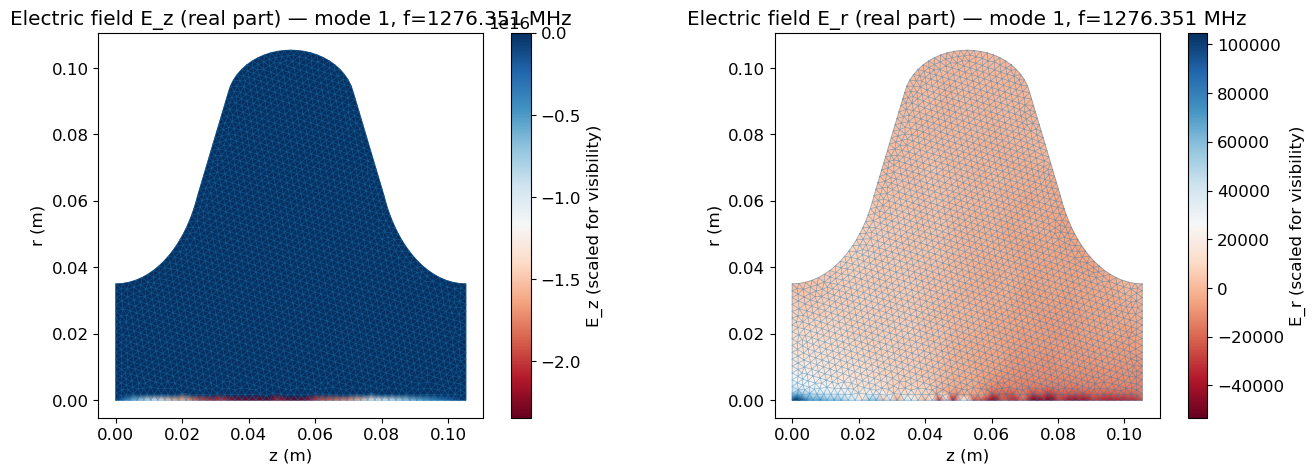

In [164]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
tpc_z = ax1.tripcolor(points[:,0], points[:,1], cells, Ez_plot, shading='gouraud', cmap='RdBu')
tpc_r = ax2.tripcolor(points[:,0], points[:,1], cells, Er_plot, shading='gouraud', cmap='RdBu')
plt.colorbar(tpc_z, label='E_z (scaled for visibility)')
plt.colorbar(tpc_r, label='E_r (scaled for visibility)')
ax1.triplot(points[:,0], points[:,1], cells, lw=0.5, alpha=0.5)
ax1.set_aspect('equal')
ax1.set_title(f"Electric field E_z (real part) — mode {mode_index+1}, f={freqs[mode_index]/1e6:.3f} MHz")
ax1.set_xlabel("z (m)")
ax1.set_ylabel("r (m)")
ax2.triplot(points[:,0], points[:,1], cells, lw=0.5, alpha=0.5)
ax2.set_aspect('equal')
ax2.set_title(f"Electric field E_r (real part) — mode {mode_index+1}, f={freqs[mode_index]/1e6:.3f} MHz")
ax2.set_xlabel("z (m)")
ax2.set_ylabel("r (m)")

plt.show()

Inside H-grad magnitude: min=1.617e+01, max=5.965e+05, mean=1.677e+04
Inside H-grad magnitude: min=1.617e+01, max=5.965e+05, mean=1.677e+04


<Figure size 800x600 with 0 Axes>

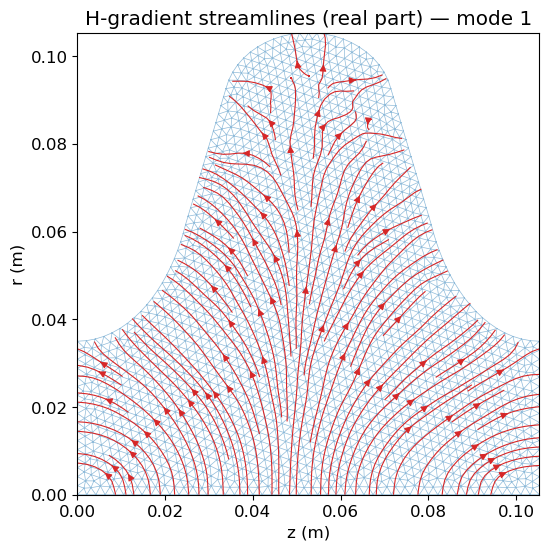

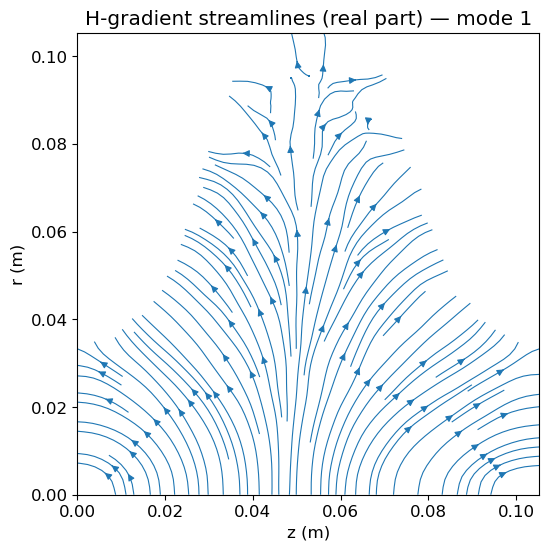

In [162]:
# --- Additional: plot streamlines for H-gradient (use grad H = [dH/dz, dH/dr]) ---
# Interpolate nodal gradients dH_dz, dH_dr (already computed in Cell 7) onto same grid
interp_dHdz = LinearTriInterpolator(triang, dH_dz.real)
interp_dHdr = LinearTriInterpolator(triang, dH_dr.real)

HZ_grid = np.zeros_like(Z, dtype=float)
HR_grid = np.zeros_like(Z, dtype=float)

vals_dHdz = interp_dHdz(pts_x, pts_y)
vals_dHdr = interp_dHdr(pts_x, pts_y)

vals_dHdz = _to_float_arr(vals_dHdz)
vals_dHdr = _to_float_arr(vals_dHdr)

HZ_grid_flat = HZ_grid.ravel()
HR_grid_flat = HR_grid.ravel()
HZ_grid_flat[inside_idx_flat] = vals_dHdz
HR_grid_flat[inside_idx_flat] = vals_dHdr
HZ_grid = HZ_grid_flat.reshape(HZ_grid.shape)
HR_grid = HR_grid_flat.reshape(HR_grid.shape)

# Replace NaNs
HZ_grid = np.nan_to_num(HZ_grid, nan=0.0)
HR_grid = np.nan_to_num(HR_grid, nan=0.0)

# Diagnostic for H-gradient magnitude
Hgrad_mag = np.sqrt(HZ_grid[tri_ids!=-1]**2 + HR_grid[tri_ids!=-1]**2)
print(f"Inside H-grad magnitude: min={Hgrad_mag.min():.3e}, max={Hgrad_mag.max():.3e}, mean={Hgrad_mag.mean():.3e}")

# Plot H-gradient streamlines (real part)
plt.figure(figsize=(8,6))
# --- Additional: plot streamlines for H-gradient (use grad H = [dH/dz, dH/dr]) ---
# Interpolate nodal gradients dH_dz, dH_dr (already computed in Cell 7) onto same grid
interp_dHdz = LinearTriInterpolator(triang, dH_dz.real)
interp_dHdr = LinearTriInterpolator(triang, dH_dr.real)

HZ_grid = np.zeros_like(Z, dtype=float)
HR_grid = np.zeros_like(Z, dtype=float)

vals_dHdz = interp_dHdz(pts_x, pts_y)
vals_dHdr = interp_dHdr(pts_x, pts_y)

vals_dHdz = _to_float_arr(vals_dHdz)
vals_dHdr = _to_float_arr(vals_dHdr)

HZ_grid_flat = HZ_grid.ravel()
HR_grid_flat = HR_grid.ravel()
HZ_grid_flat[inside_idx_flat] = vals_dHdz
HR_grid_flat[inside_idx_flat] = vals_dHdr
HZ_grid = HZ_grid_flat.reshape(HZ_grid.shape)
HR_grid = HR_grid_flat.reshape(HR_grid.shape)

# Replace NaNs
HZ_grid = np.nan_to_num(HZ_grid, nan=0.0)
HR_grid = np.nan_to_num(HR_grid, nan=0.0)

# Diagnostic for H-gradient magnitude
Hgrad_mag = np.sqrt(HZ_grid[tri_ids!=-1]**2 + HR_grid[tri_ids!=-1]**2)
print(f"Inside H-grad magnitude: min={Hgrad_mag.min():.3e}, max={Hgrad_mag.max():.3e}, mean={Hgrad_mag.mean():.3e}")

# Plot H-gradient streamlines (real part)
plt.figure(figsize=(8,6))
plt.triplot(points[:,0], points[:,1], cells, lw=0.5, alpha=0.5)
plt.gca().set_aspect('equal')
plt.streamplot(
    z_grid,
    r_grid,
    HZ_grid,    # U (x-direction) = dH/dz
    HR_grid,    # V (y-direction) = dH/dr
    density=2.0,
    linewidth=0.8,
    arrowsize=1.0,
    color='tab:red',
    start_points=seed_points if seed_points.size>0 else None
)
plt.title(f"H-gradient streamlines (real part) — mode {mode_index+1}")
plt.xlabel("z (m)")
plt.ylabel("r (m)")
plt.gca().set_aspect('equal')
plt.xlim(z_min, z_max)
plt.ylim(r_min, r_max)
plt.show()

plt.streamplot(
    z_grid,
    r_grid,
    HZ_grid,    # U (x-direction) = dH/dz
    HR_grid,    # V (y-direction) = dH/dr
    density=2.0,
    linewidth=0.8,
    arrowsize=1.0,
    color='tab:blue',
    start_points=seed_points if seed_points.size>0 else None
)
plt.title(f"H-gradient streamlines (real part) — mode {mode_index+1}")
plt.xlabel("z (m)")
plt.ylabel("r (m)")
plt.gca().set_aspect('equal')
plt.xlim(z_min, z_max)
plt.ylim(r_min, r_max)
plt.show()
